In [439]:
import pandas as pd

df = pd.read_csv("employee_performance_dirty_dataset.csv")

# Data Understanding

In [442]:
print(" row   col")
df.shape

 row   col


(1530, 12)

In [450]:
df.head(8)

,EmployeeID,Age,Gender,Department,EducationLevel,WorkMode,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction,Promotion
0,10001,59.0,Female,Operations,Bachelor,Hybrid,30,12430.0,167.0,62,8.0,No
1,10002,49.0,Male,IT,PhD,Hybrid,33,5188.0,204.0,99,8.0,No
2,10003,35.0,Female,IT,Diploma,Hybrid,5,11172.0,160.0,64,7.0,No
3,10004,NaN,Female,Marketing,Bachelor,Hybrid,33,12683.0,158.0,81,10.0,No
4,10005,41.0,Female,Sales,Bachelor,Office,14,10895.0,222.0,83,9.0,No
5,10006,59.0,Female,Sales,Bachelor,Remote,13,14188.0,181.0,92,4.0,No
6,10007,39.0,Male,Finance,Bachelor,Remote,5,12938.0,161.0,80,7.0,No
7,10008,43.0,Female,Marketing,Master,Remote,31,12525.0,180.0,63,NaN,No


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        1530 non-null   int64  
 1   Age               1459 non-null   float64
 2   Gender            1530 non-null   object 
 3   Department        1457 non-null   object 
 4   EducationLevel    1530 non-null   object 
 5   WorkMode          1530 non-null   object 
 6   ExperienceYears   1530 non-null   int64  
 7   MonthlySalarySAR  1460 non-null   float64
 8   MonthlyHours      1530 non-null   float64
 9   PerformanceScore  1530 non-null   int64  
 10  JobSatisfaction   1459 non-null   float64
 11  Promotion         1530 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 143.6+ KB


In [216]:
num_col = df.select_dtypes(exclude=object).columns.tolist()
cat_col = df.select_dtypes(include=object).columns.tolist()

In [218]:
print(num_col)
print(cat_col)

['EmployeeID', 'Age', 'ExperienceYears', 'MonthlySalarySAR', 'MonthlyHours', 'PerformanceScore', 'JobSatisfaction']
['Gender', 'Department', 'EducationLevel', 'WorkMode', 'Promotion']


In [220]:
df[num_col].describe()

,EmployeeID,Age,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction
count,1530.000000,1459.000000,1530.000000,1460.000000,1530.000000,1530.000000,1459.000000
mean,10752.274510,40.409184,16.847712,15208.660959,182.052941,74.822876,5.461960
std,434.143057,13.571250,10.079394,25028.272364,36.622147,14.789453,2.860573
min,10001.000000,-39.000000,0.000000,-29641.000000,96.000000,50.000000,1.000000
25%,10375.250000,31.000000,8.000000,10484.750000,163.000000,63.000000,3.000000
50%,10754.500000,42.000000,17.000000,13643.500000,180.000000,74.000000,5.000000
75%,11129.750000,51.000000,25.000000,16843.500000,198.000000,88.000000,8.000000
max,11500.000000,60.000000,34.000000,498606.000000,594.000000,100.000000,10.000000


In [222]:
df[cat_col].describe()

,Gender,Department,EducationLevel,WorkMode,Promotion
count,1530,1457,1530,1530,1530
unique,8,6,4,3,2
top,Female,Sales,Bachelor,Remote,No
freq,780,264,864,527,1288


# Data Cleaning

## Duplicated rows

In [226]:
df[df.duplicated(keep=False)].sort_values('EmployeeID')

,EmployeeID,Age,Gender,Department,EducationLevel,WorkMode,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction,Promotion
75,10076,49.0,Female,NaN,Bachelor,Hybrid,6,12103.0,96.0,96,4.0,Yes
1501,10076,49.0,Female,NaN,Bachelor,Hybrid,6,12103.0,96.0,96,4.0,Yes
1500,10092,25.0,Female,HR,Bachelor,Office,6,19130.0,209.0,62,3.0,Yes
91,10092,25.0,Female,HR,Bachelor,Office,6,19130.0,209.0,62,3.0,Yes
101,10102,44.0,Female,Finance,Diploma,Remote,24,12790.0,133.0,97,7.0,Yes
1513,10102,44.0,Female,Finance,Diploma,Remote,24,12790.0,133.0,97,7.0,Yes
102,10103,57.0,Male,Sales,Bachelor,Office,14,13945.0,164.0,58,6.0,No
1524,10103,57.0,Male,Sales,Bachelor,Office,14,13945.0,164.0,58,6.0,No
169,10170,22.0,Male,Finance,Bachelor,Hybrid,9,11099.0,182.0,88,2.0,No
1516,10170,22.0,Male,Finance,Bachelor,Hybrid,9,11099.0,182.0,88,2.0,No


In [228]:
df = df.drop_duplicates(subset=['EmployeeID'])
df[df.duplicated(keep=False)]

,EmployeeID,Age,Gender,Department,EducationLevel,WorkMode,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction,Promotion


In [232]:
df

,Age,Gender,Department,EducationLevel,WorkMode,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction,Promotion
0,59.0,Female,Operations,Bachelor,Hybrid,30,12430.0,167.0,62,8.0,No
1,49.0,Male,IT,PhD,Hybrid,33,5188.0,204.0,99,8.0,No
2,35.0,Female,IT,Diploma,Hybrid,5,11172.0,160.0,64,7.0,No
3,NaN,Female,Marketing,Bachelor,Hybrid,33,12683.0,158.0,81,10.0,No
4,41.0,Female,Sales,Bachelor,Office,14,10895.0,222.0,83,9.0,No
...,...,...,...,...,...,...,...,...,...,...,...
1495,53.0,Male,HR,Bachelor,Remote,33,14456.0,185.0,53,7.0,Yes
1496,26.0,Male,HR,Master,Remote,9,10432.0,145.0,93,10.0,No
1497,35.0,Male,Finance,Diploma,Office,19,25074.0,177.0,99,10.0,Yes
1498,52.0,Female,HR,Bachelor,Hybrid,0,17333.0,195.0,88,6.0,Yes


In [230]:
df = df.drop(columns=['EmployeeID'])

In [234]:
num_col = df.select_dtypes(exclude=object).columns.tolist()
print(num_col)

['Age', 'ExperienceYears', 'MonthlySalarySAR', 'MonthlyHours', 'PerformanceScore', 'JobSatisfaction']


## Missing Values

In [238]:
missing = df.isnull().sum()
missing

Age                 70
Gender               0
Department          70
EducationLevel       0
WorkMode             0
ExperienceYears      0
MonthlySalarySAR    69
MonthlyHours         0
PerformanceScore     0
JobSatisfaction     70
Promotion            0
dtype: int64

In [240]:
df['Age'] = df['Age'].abs().fillna(df['Age'].abs().mean())
df['Age']

"""
Before:
20
30
-39
NaN

After:
20
30
-39
29.67

if I do not use .abs twice
"""

'\nBefore:\n20\n30\n-39\nNaN\n\nAfter:\n20\n30\n-39\n29.67\n\nif I do not use .abs twice\n'

In [242]:
df['Department'] = df['Department'].fillna(df['Department'].mode()[0]) 
df['Department']
# mode() returns a Series, so [0] is used to extract the most frequent value
# e.g.:   0    Sales
#         dtype: object

0       Operations
1               IT
2               IT
3        Marketing
4            Sales
           ...    
1495            HR
1496            HR
1497       Finance
1498            HR
1499     Marketing
Name: Department, Length: 1500, dtype: object

In [244]:
df['MonthlySalarySAR'] = df['MonthlySalarySAR'].abs().fillna(df['MonthlySalarySAR'].abs().mean())
df['MonthlySalarySAR']

0       12430.0
1        5188.0
2       11172.0
3       12683.0
4       10895.0
         ...   
1495    14456.0
1496    10432.0
1497    25074.0
1498    17333.0
1499    14572.0
Name: MonthlySalarySAR, Length: 1500, dtype: float64

In [246]:
df['JobSatisfaction'] = df['JobSatisfaction'].fillna(df['JobSatisfaction'].mode()[0])
df['JobSatisfaction']

0        8.0
1        8.0
2        7.0
3       10.0
4        9.0
        ... 
1495     7.0
1496    10.0
1497    10.0
1498     6.0
1499     1.0
Name: JobSatisfaction, Length: 1500, dtype: float64

In [248]:
missing = df.isna().sum()
missing

Age                 0
Gender              0
Department          0
EducationLevel      0
WorkMode            0
ExperienceYears     0
MonthlySalarySAR    0
MonthlyHours        0
PerformanceScore    0
JobSatisfaction     0
Promotion           0
dtype: int64

In [250]:
df[num_col].describe()

,Age,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,40.941259,16.944000,15631.141859,182.172000,74.811333,5.392667
std,11.440978,10.098491,24441.947807,36.750185,14.806189,2.813258
min,18.000000,0.000000,42.000000,96.000000,50.000000,1.000000
25%,31.000000,8.000000,10779.500000,163.000000,63.000000,3.000000
50%,41.000000,17.000000,14021.500000,180.000000,74.000000,5.000000
75%,51.000000,26.000000,16774.750000,198.000000,88.000000,8.000000
max,60.000000,34.000000,498606.000000,594.000000,100.000000,10.000000


In [252]:
df[cat_col].describe()

,Gender,Department,EducationLevel,WorkMode,Promotion
count,1500,1500,1500,1500,1500
unique,8,6,4,3,2
top,Female,Sales,Bachelor,Remote,No
freq,764,327,844,518,1270


## Wrong Input

In [254]:
Gender_col = df['Gender'].unique()
Gender_col

array(['Female', 'Male', 'M', 'male', 'MALE', 'F', 'female', 'FEMALE'],
      dtype=object)

In [256]:
df['Gender'] = df['Gender'].replace({'M' : 'Male' , 'male' : 'Male', 'MALE' : 'Male',
                                    'F' : 'Female' , 'female' : 'Female' , 'FEMALE' : 'Female'
                                    })

In [258]:
Gender_col = df['Gender'].unique()
Gender_col

array(['Female', 'Male'], dtype=object)

# Outlier

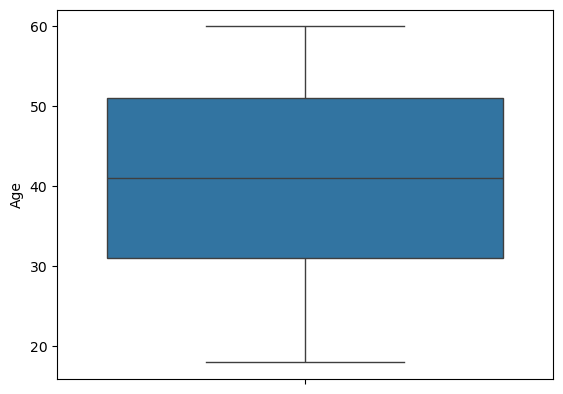

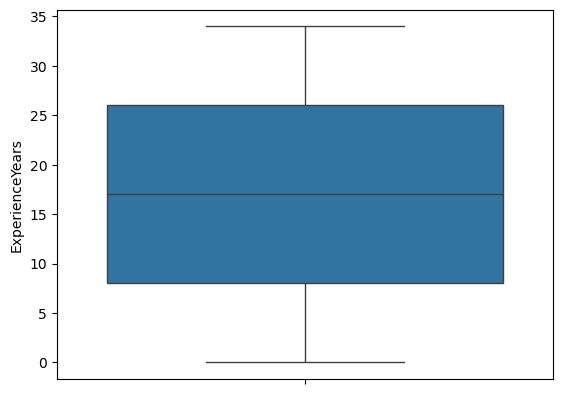

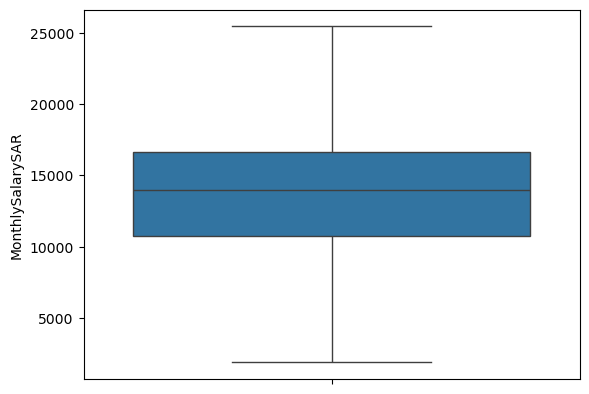

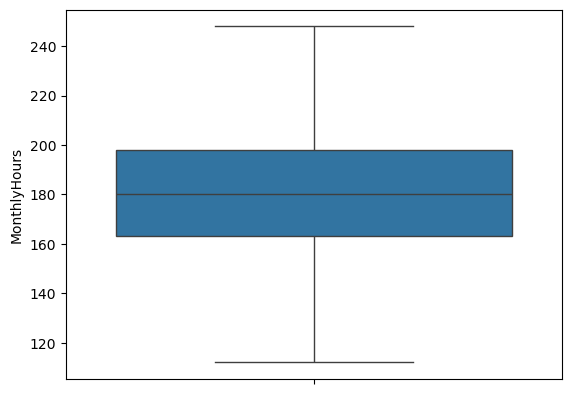

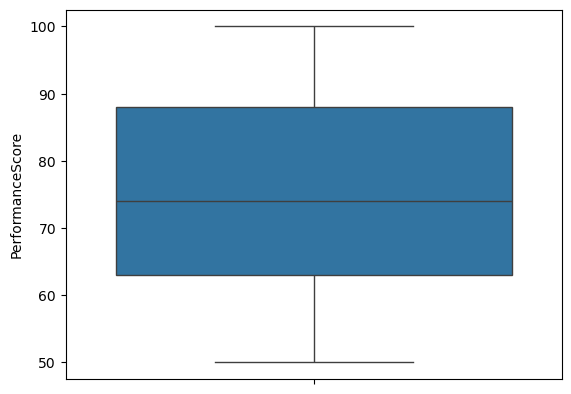

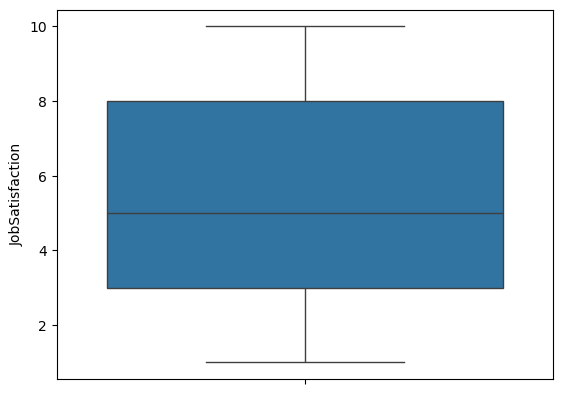

In [307]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_col:
    plt.figure()
    sns.boxplot(df[col])
    plt.show()

In [370]:
def remove_outlier(df):

    for col in num_col:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - IQR * 1.5
        upper = Q3 + IQR * 1.5

        df = df[( df[col] >= lower ) & (df[col] <= upper)]
        
    return df

df = remove_outlier(df)

# EDA
## Univariate

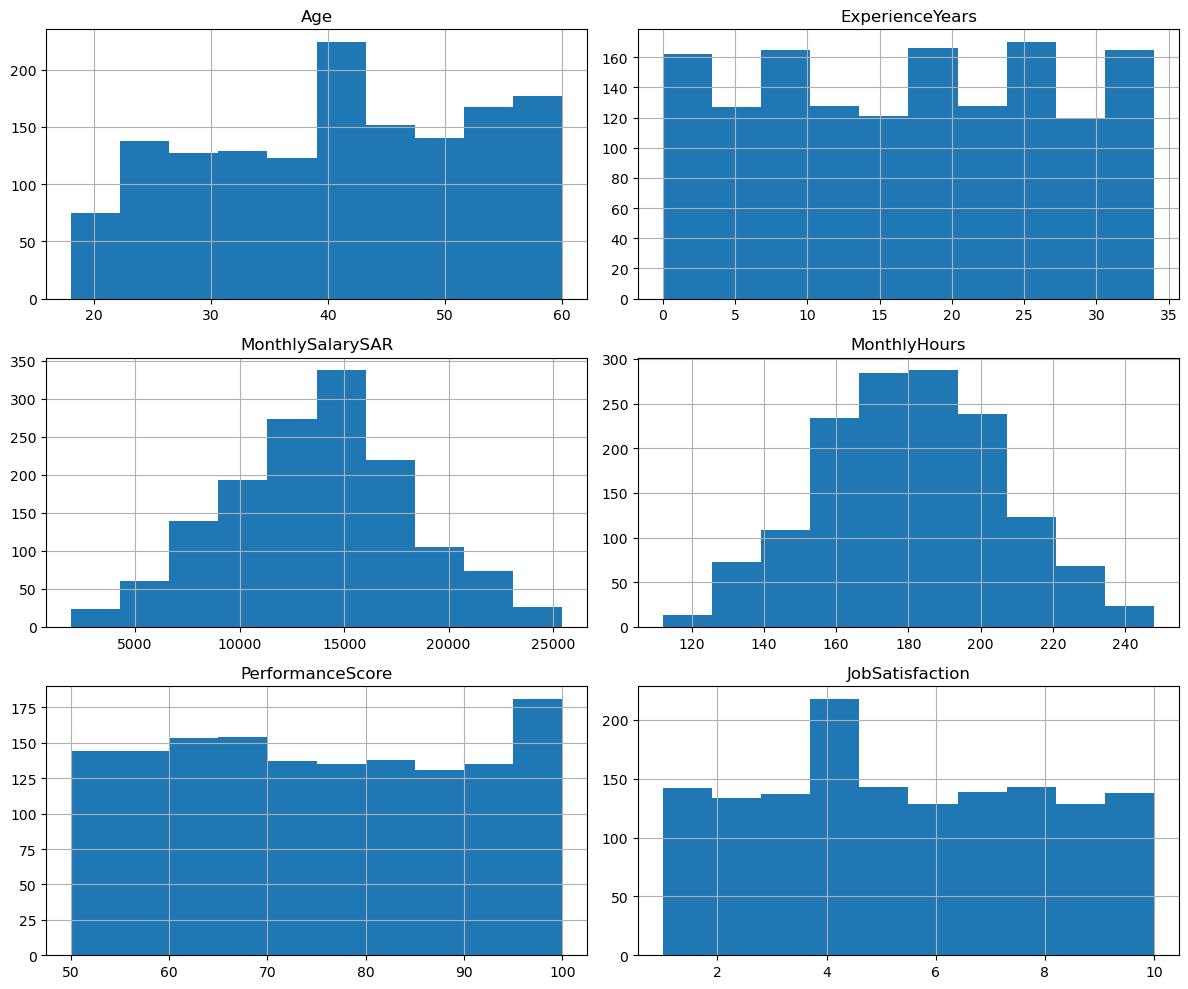

In [301]:
df[num_col].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

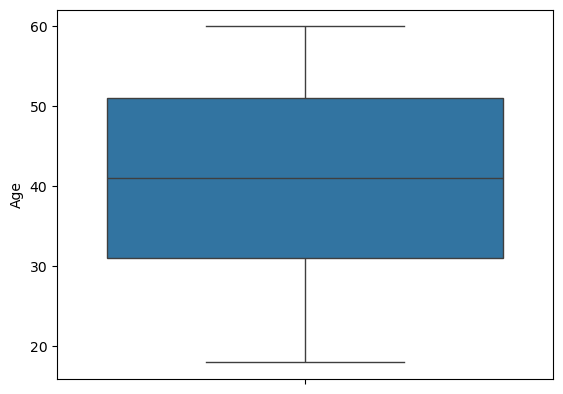

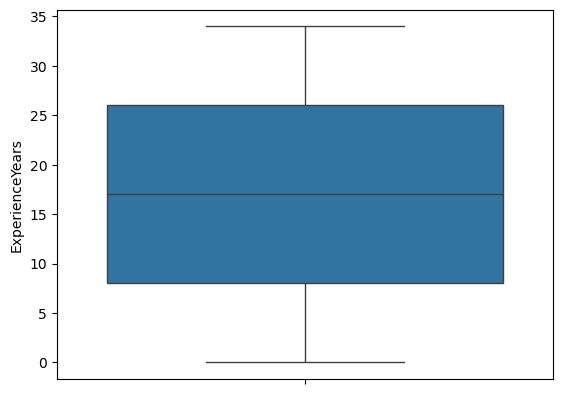

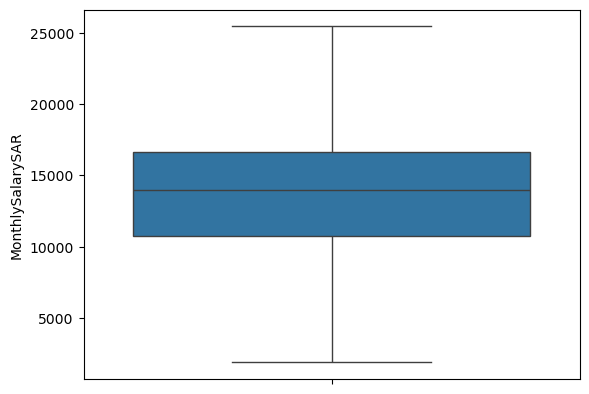

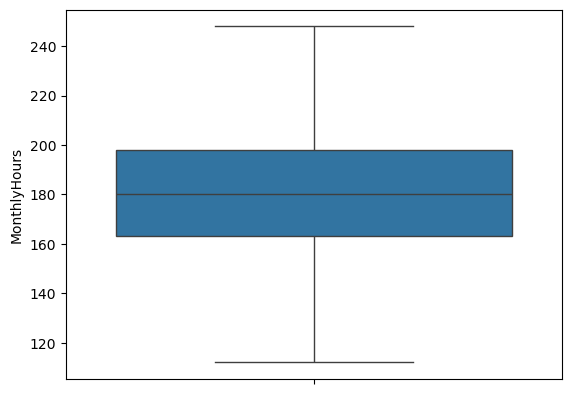

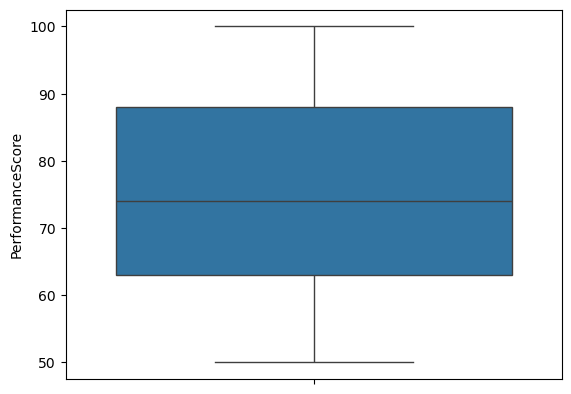

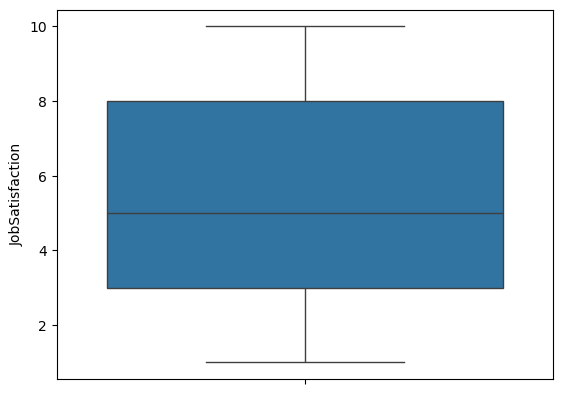

In [351]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_col:
    plt.figure()
    sns.boxplot(df[col])
    plt.show()

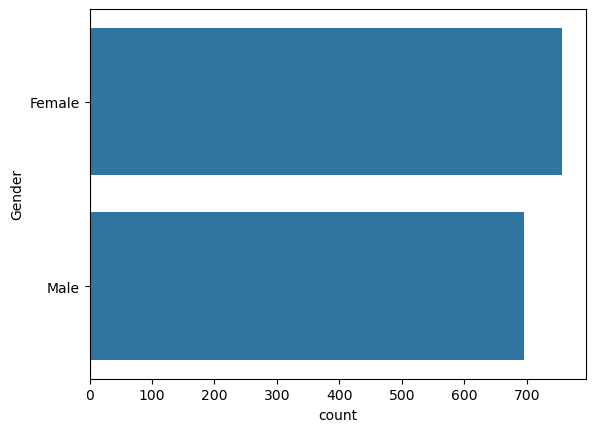

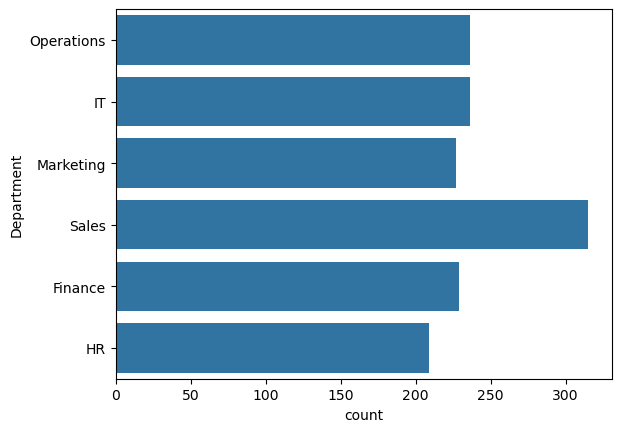

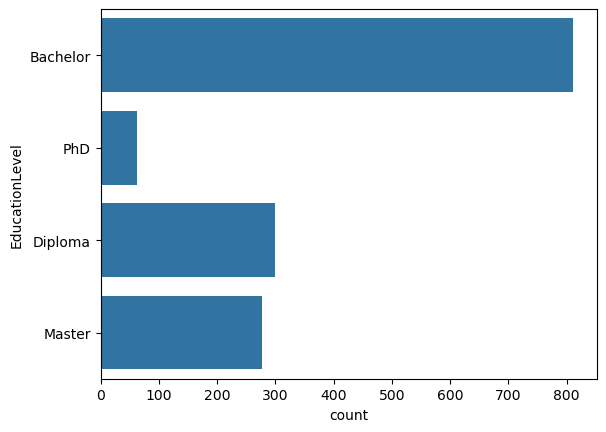

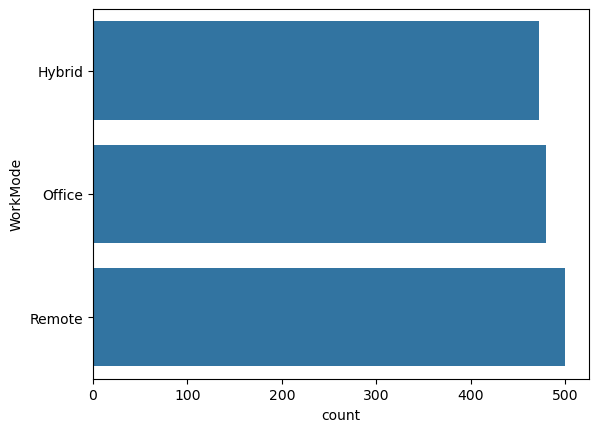

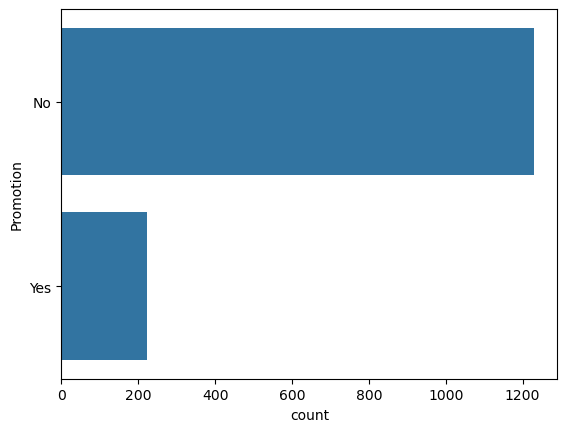

In [321]:
for col in cat_col:
    sns.countplot(data=df[col])
    plt.show()

# Bivariate

In [334]:
df[num_col].corr()

,Age,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction
Age,1.000000,0.006883,0.009596,-0.014895,-0.042036,-0.039020
ExperienceYears,0.006883,1.000000,-0.023108,-0.013282,-0.033438,-0.012167
MonthlySalarySAR,0.009596,-0.023108,1.000000,0.018188,-0.022725,0.021163
MonthlyHours,-0.014895,-0.013282,0.018188,1.000000,0.018947,-0.002436
PerformanceScore,-0.042036,-0.033438,-0.022725,0.018947,1.000000,-0.019271
JobSatisfaction,-0.039020,-0.012167,0.021163,-0.002436,-0.019271,1.000000


<Axes: xlabel='ExperienceYears', ylabel='MonthlySalarySAR'>

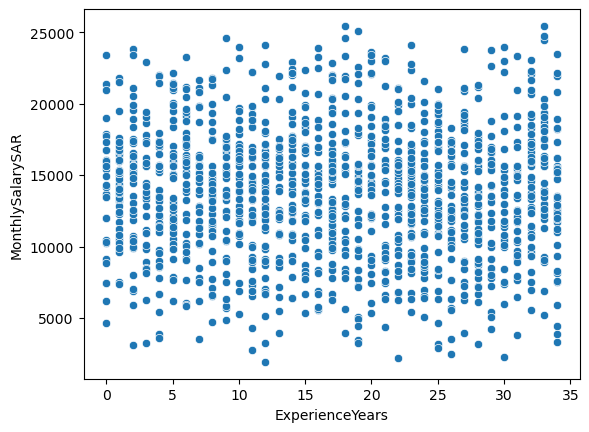

In [355]:
sns.scatterplot(x='ExperienceYears', y='MonthlySalarySAR', data=df)

<Axes: xlabel='PerformanceScore', ylabel='Promotion'>

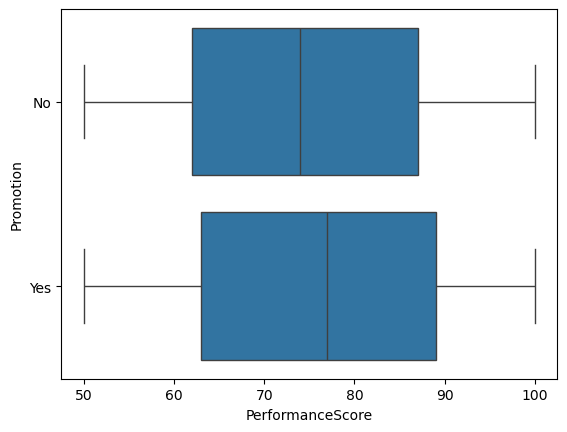

In [363]:
sns.boxplot(x='PerformanceScore', y='Promotion', data=df)

<Axes: xlabel='Department', ylabel='MonthlySalarySAR'>

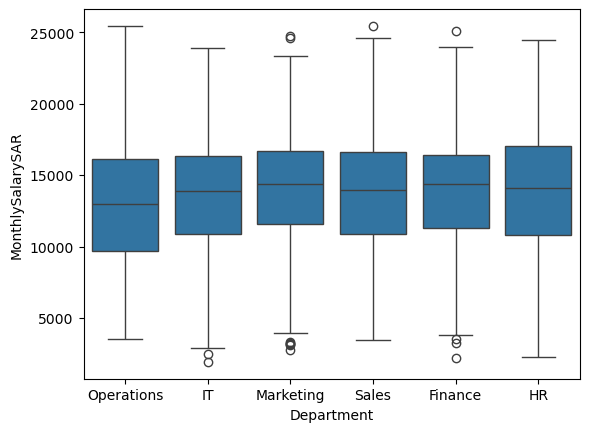

In [372]:
sns.boxplot(x='Department', y='MonthlySalarySAR', data=df)

## Multivariate Analysis

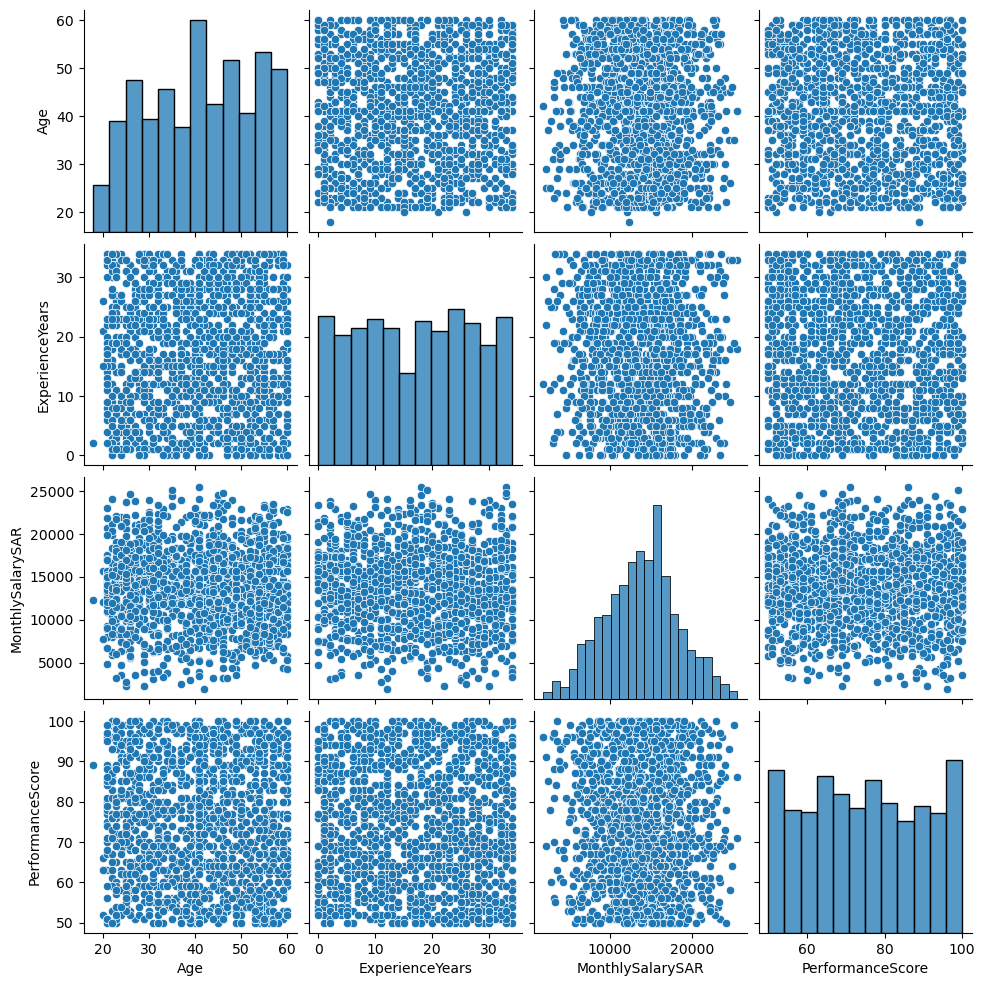

In [366]:
selectef_col = ['Age', 'ExperienceYears', 'MonthlySalarySAR', 'PerformanceScore']
sns.pairplot(df[selectef_col])

In [374]:
# Save cleaned dataset
df.to_csv('employee_performance_cleaned.csv', index=False)

In [376]:
pd.read_csv('employee_performance_cleaned.csv').head()

,Age,Gender,Department,EducationLevel,WorkMode,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction,Promotion
0,59.000000,Female,Operations,Bachelor,Hybrid,30,12430.0,167.0,62,8.0,No
1,49.000000,Male,IT,PhD,Hybrid,33,5188.0,204.0,99,8.0,No
2,35.000000,Female,IT,Diploma,Hybrid,5,11172.0,160.0,64,7.0,No
3,40.941259,Female,Marketing,Bachelor,Hybrid,33,12683.0,158.0,81,10.0,No
4,41.000000,Female,Sales,Bachelor,Office,14,10895.0,222.0,83,9.0,No


# ML

In [379]:
import pandas as pd
df = pd.read_csv('employee_performance_cleaned.csv')
df.head()

,Age,Gender,Department,EducationLevel,WorkMode,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction,Promotion
0,59.000000,Female,Operations,Bachelor,Hybrid,30,12430.0,167.0,62,8.0,No
1,49.000000,Male,IT,PhD,Hybrid,33,5188.0,204.0,99,8.0,No
2,35.000000,Female,IT,Diploma,Hybrid,5,11172.0,160.0,64,7.0,No
3,40.941259,Female,Marketing,Bachelor,Hybrid,33,12683.0,158.0,81,10.0,No
4,41.000000,Female,Sales,Bachelor,Office,14,10895.0,222.0,83,9.0,No


In [381]:
num_col = df.select_dtypes(include = 'number').columns.tolist()
cat_col = df.select_dtypes(exclude = 'number').columns.tolist()

print(num_col)
cat_col

['Age', 'ExperienceYears', 'MonthlySalarySAR', 'MonthlyHours', 'PerformanceScore', 'JobSatisfaction']


['Gender', 'Department', 'EducationLevel', 'WorkMode', 'Promotion']

# Encoded Categorical Features

In [385]:
df['Promotion'].value_counts()

Promotion
No     1229
Yes     223
Name: count, dtype: int64

In [387]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Promotion'] = le.fit_transform(df['Promotion'])

In [401]:
df['Promotion'].value_counts()

Promotion
0    1229
1     223
Name: count, dtype: int64

In [405]:
df = pd.get_dummies(df, columns = ['Gender','Department','EducationLevel','WorkMode'], drop_first= True)

In [409]:
df.head()

,Age,ExperienceYears,MonthlySalarySAR,MonthlyHours,PerformanceScore,JobSatisfaction,Promotion,Gender_Male,Department_HR,Department_IT,Department_Marketing,Department_Operations,Department_Sales,EducationLevel_Diploma,EducationLevel_Master,EducationLevel_PhD,WorkMode_Office,WorkMode_Remote
0,59.000000,30,12430.0,167.0,62,8.0,0,False,False,False,False,True,False,False,False,False,False,False
1,49.000000,33,5188.0,204.0,99,8.0,0,True,False,True,False,False,False,False,False,True,False,False
2,35.000000,5,11172.0,160.0,64,7.0,0,False,False,True,False,False,False,True,False,False,False,False
3,40.941259,33,12683.0,158.0,81,10.0,0,False,False,False,True,False,False,False,False,False,False,False
4,41.000000,14,10895.0,222.0,83,9.0,0,False,False,False,False,False,True,False,False,False,True,False


In [419]:
X = df.drop(columns=['Promotion'])
y = df['Promotion']

In [425]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 32)

In [429]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [431]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [433]:
y_predict = model.predict(X_test)

In [437]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_predict))

print("\nClassification Report:")
print(classification_report(y_test, y_predict))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predict))

Accuracy: 0.563573883161512

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.58      0.69       248
           1       0.16      0.47      0.24        43

    accuracy                           0.56       291
   macro avg       0.51      0.52      0.47       291
weighted avg       0.76      0.56      0.63       291


Confusion Matrix:
[[144 104]
 [ 23  20]]
